## A trial to predict weekly stock volatility of tesla on wikipedia statistics. 4.04
---

In [4]:
import pandas as pd
import importlib
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import edits_with_volume_plot as ewv
import tensorflow
import tensorflow_hub as hub
from statsmodels.tsa.stattools import adfuller
import numpy as np
_ = importlib.reload(ewv)

"""A shortcut for loading files from data directory"""
DR = "data/datasets/"

In [5]:
wiki = ewv.prepare_wiki_df(pd.read_csv(f"{DR}WIKI_tesla.csv"))
stock = ewv.prepare_stock_df(pd.read_csv(f"{DR}STOCK_tesla.csv"))

stock["log_return"] = np.log(stock['Close'] / stock['Close'].shift(1))
weekly_vol = stock.groupby(pd.Grouper(key='Date', freq='W'))['log_return'].std()
weekly_volume = stock.groupby(pd.Grouper(key='Date', freq='W'))['Volume'].sum()

In [19]:
wiki['is_revert'] = (wiki['sha1'] == wiki['sha1'].shift(2)).astype(int)

weekly_stats = wiki.resample('W').agg({
    'is_revert': 'sum',      # Count of reverts in that week
    'user': 'nunique',       # Unique editors participating that week
    'sha1': 'count'         # Total number of edits (for ratio calculation)
}).rename(columns={
    'is_revert': 'reverts',
    'user': 'unique_editors',
    'sha1': 'total_edits'
})

In [35]:
weekly_stats['log_vol'] = weekly_vol
weekly_stats['Stock_Volume'] = weekly_volume
weekly_stats = weekly_stats.dropna(axis=0)

In [34]:
weekly_stats

,reverts,unique_editors,total_edits,Stock_Volatility,Stock_Volume
timestamp,,,,,
2010-07-04 00:00:00+00:00,0,8,14,0.066345,739680000.0
2010-07-11 00:00:00+00:00,0,2,2,0.113633,383259000.0
2010-07-18 00:00:00+00:00,0,3,3,0.044222,231583500.0
2010-07-25 00:00:00+00:00,0,4,4,0.052045,107635500.0
2010-08-01 00:00:00+00:00,0,3,4,0.012034,45780000.0
...,...,...,...,...,...
2026-02-22 00:00:00+00:00,0,0,0,0.008725,214532000.0
2026-03-01 00:00:00+00:00,0,2,16,0.024404,293561800.0
2026-03-08 00:00:00+00:00,0,2,8,0.024194,301991600.0


In [63]:
df = weekly_stats
vol = df.log_vol

### 1. Preparing the predicted value to be stationary (detrending/deseasoning)
---

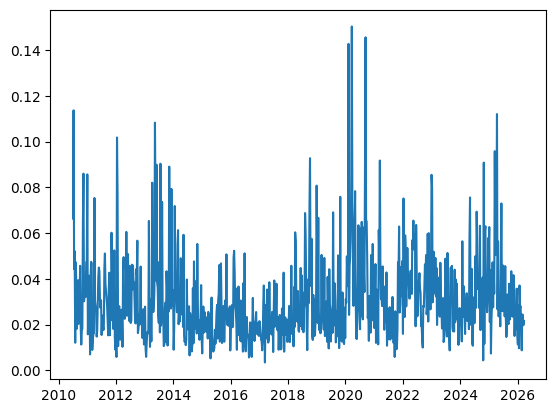

In [39]:
plt.plot(vol)

In [64]:
df["edits_l1"] = df["total_edits"].shift(1)
df["unique_editors_l1"] = df["unique_editors"].shift(1)
df["reverts_l1"] = df["reverts"].shift(1)
df['log_vol_lag1'] = df['log_vol'].shift(1)
df['log_vol_lag2'] = df['log_vol'].shift(2)

df = df.dropna(axis=0)

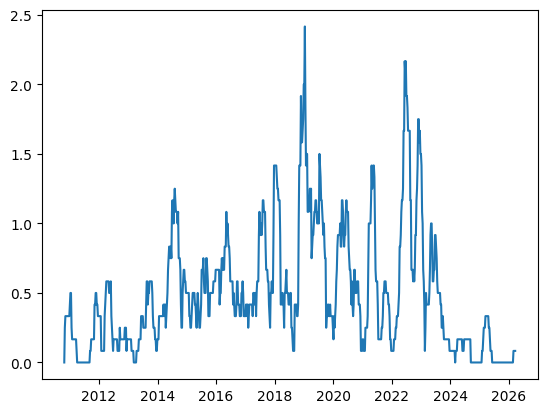

In [66]:
# --- Option A: Rolling Z-Score (Best for "Abnormal" signals) ---
window_size = 12  # Adjust based on your frequency (e.g., 12 weeks or 30 days)

rolling_mean = df['reverts'].rolling(window=window_size).mean()
rolling_std = df['reverts'].rolling(window=window_size).std()

# df['reverts_z_rolling'] = (df['reverts'] - rolling_mean) / rolling_std

# # --- Option B: Global Z-Score (Static baseline) ---
# df['reverts_z_global'] = (df['reverts'] - df['reverts'].mean()) / df['reverts'].std()

# # --- Create a Lag of the Z-score for your regression ---
# df['reverts_z_l1'] = df['reverts_z_rolling'].shift(1)

# # Clean up NaNs created by the rolling window and the shift
# df = df.dropna()

plt.plot(rolling_mean)

The ADF test suggests the data is already stationary:

In [40]:
result = adfuller(vol)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print(f'Critial Value ({key}): {value}')

ADF Statistic: -7.742875376218618
p-value: 1.0505147730006494e-11
Critial Value (1%): -3.438399099271788
Critial Value (5%): -2.8650928286782857
Critial Value (10%): -2.568661836350634


In [65]:
df = df.copy()

# --- 4. Drop missing due to lags ---
reg_df = df.dropna()

# --- 5. Define X and y ---
X = reg_df[['log_vol_lag1', 'log_vol_lag2', "reverts_l1", "unique_editors_l1", "edits_l1"]]
X = sm.add_constant(X)

y = reg_df['log_vol']

# --- 6. Run regression ---
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_vol   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     17.99
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           6.03e-17
Time:                        22:29:12   Log-Likelihood:                 2125.9
No. Observations:                 816   AIC:                            -4240.
Df Residuals:                     810   BIC:                            -4212.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0187      0.00

In [52]:
model.f_test("z_reverts = z_unique_editors = z_total_edits = 0")

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=3.273701890098929, p=0.020748888280874157, df_denom=669, df_num=3>